# Lasso Regression for Used-Car Price Prediction

## Objective

This notebook develops and evaluates Lasso Regression for predicting used-car prices.

The analysis will:

- use the same train-test split and preprocessing workflow as the previous models,
- model the log-transformed `Price` target,
- select the best `alpha` using cross-validation on training data,
- evaluate performance using MAE, RMSE, and R²,
- examine coefficient shrinkage and feature selection,
- compare Lasso with Linear and Ridge Regression.

## 1. Import Required Libraries



In [28]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_validate
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load and Validate the Dataset

The original used-car dataset will be loaded from `data/raw/car_price_data.csv`.

Basic validation will confirm the dataset shape, duplicate records, target availability, and whether `Price` contains missing or non-positive values. These checks ensure that the correct raw dataset is used before splitting or preprocessing.

In [4]:
data_path = "../data/raw/car_price_data.csv"

df = pd.read_csv(data_path)


print("Dataset shape:", df.shape)
print("Duplicate records:", df.duplicated().sum())
print("Missing Price values:", df["Price"].isna().sum())
print("Non-positive Price values:", (df["Price"] <= 0).sum())

df.head()

Dataset shape: (2059, 20)
Duplicate records: 0
Missing Price values: 0
Non-positive Price values: 0


,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


### Initial Validation Observations

- The dataset contains 2,059 observations and 20 original columns.
- No duplicate records were found.
- The target variable, `Price`, contains no missing values.
- No zero or negative Price values were identified.
- The dataset is suitable for train-test splitting and log transformation.

## 3. Create the Train-Test Split

The predictor variables and target variable will be separated before preprocessing.

The dataset will be divided into 80% training data and 20% test data using `random_state=42`. The same split used for Linear and Ridge Regression is retained for a fair model comparison.

Feature engineering and preprocessing will be fitted using the training data only to prevent data leakage.

X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

### Train-Test Split Observations

- The training set contains 1,647 observations.
- The test set contains 412 observations.
- Each observation has 19 original predictor columns before feature engineering.
- The split exactly matches the Linear and Ridge Regression notebooks.
- The test set remains untouched for final model evaluation.

## 4. Apply Log Transformation to the Target

The `Price` target is strongly right-skewed. Therefore, `log1p` transformation will be applied separately to the training and test targets.

Lasso Regression will be trained using the log-transformed training target. Predictions will later be converted back to the original Price scale using `expm1` before calculating MAE, RMSE, and R².

This transformation previously reduced training-target skewness from approximately 4.45 to 0.46 and produced better regression performance.

In [6]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("Original training Price skewness:", round(y_train.skew(), 2))
print("Log-transformed training Price skewness:", round(y_train_log.skew(), 2))

Original training Price skewness: 4.45
Log-transformed training Price skewness: 0.46


### Target Transformation Observations

- The original training Price distribution has strong positive skewness of 4.45.
- Log transformation reduces the skewness to 0.46.
- The transformed target is substantially more balanced and suitable for Lasso Regression.
- The same target transformation used in the previous models is retained for fair comparison.

## 5. Perform Feature Engineering

The same feature-engineering approach used in the previous notebooks will be retained for consistency.

The following numerical features will be created:

- `Vehicle_Age` from `Year`,
- `Engine_CC` from `Engine`,
- `Power_BHP` and `Power_RPM` from `Max Power`,
- `Torque_NM` and `Torque_RPM_Clean` from `Max Torque`.

Torque values reported in `kgm` will be converted to Newton-metres. After extraction, the original text-based technical columns will be removed.

Feature engineering will be applied separately to the training and test data after the split.

In [7]:
def extract_number(column):
    return pd.to_numeric(
        column.astype("string").str.extract(r"(\d+\.?\d*)")[0],
        errors="coerce"
    )


def extract_rpm(column):
    cleaned_column = column.astype("string").str.replace(",", "", regex=False)

    return pd.to_numeric(
        cleaned_column.str.extract(r"(?:@|at)\s*(\d+\.?\d*)")[0],
        errors="coerce"
    )


def engineer_features(data):
    data = data.copy()

    data["Vehicle_Age"] = 2022 - data["Year"]
    data["Engine_CC"] = extract_number(data["Engine"])
    data["Power_BHP"] = extract_number(data["Max Power"])
    data["Power_RPM"] = extract_rpm(data["Max Power"])
    data["Torque_NM"] = extract_number(data["Max Torque"])
    data["Torque_RPM_Clean"] = extract_rpm(data["Max Torque"])

    kgm_rows = data["Max Torque"].astype("string").str.contains(
        "kgm", case=False, na=False
    )
    data.loc[kgm_rows, "Torque_NM"] *= 9.80665

    data = data.drop(
        columns=["Year", "Engine", "Max Power", "Max Torque"]
    )

    return data


X_train_fe = engineer_features(X_train)
X_test_fe = engineer_features(X_test)

print("Training shape after feature engineering:", X_train_fe.shape)
print("Test shape after feature engineering:", X_test_fe.shape)

Training shape after feature engineering: (1647, 21)
Test shape after feature engineering: (412, 21)


### Feature Engineering Observations

- The training and test sets each contain 21 features after feature engineering.
- Useful numerical information was extracted from the original technical text columns.
- Torque values reported in `kgm` were converted to Newton-metres.
- Feature engineering was performed after the train-test split.
- The resulting shapes match the previous model notebooks.

## 6. Build the Preprocessing Pipeline

Numerical and categorical features will be identified from the feature-engineered training data.

The preprocessing pipeline will:

- impute numerical missing values using the training median,
- add numerical missing-value indicators,
- standardize numerical features,
- replace missing categorical values with `Missing`,
- group categories occurring fewer than five times,
- one-hot encode categorical features,
- ignore unseen categories in the test set.

Preprocessing will remain inside the model pipeline so that every transformation is fitted only on training data during model fitting and cross-validation.

In [8]:
numerical_features = X_train_fe.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train_fe.select_dtypes(
    exclude=np.number
).columns.tolist()

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        min_frequency=5
    ))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Total input features:", len(numerical_features) + len(categorical_features))

Numerical features: 12
Categorical features: 9
Total input features: 21


### Preprocessing Pipeline Observations

- The feature-engineered data contains 12 numerical and 9 categorical input features.
- Numerical features will be imputed, provided with missing indicators, and standardized.
- Categorical features will be imputed, grouped by frequency, and one-hot encoded.
- The first category will be dropped to reduce redundant dummy variables.
- The complete preprocessing workflow will be fitted inside the Lasso pipeline.

## 7. Train a Basic Lasso Regression Model

Lasso Regression extends Linear Regression by adding an L1 penalty. This penalty shrinks coefficients and can set some coefficients exactly to zero, allowing Lasso to perform automatic feature selection.

The regularization strength is controlled by `alpha`:

- an `alpha` close to zero applies weak regularization,
- a larger `alpha` applies stronger shrinkage,
- excessive regularization can remove useful features and cause underfitting.

A basic Lasso model with `alpha=1.0` will first be trained as an initial reference. A larger `max_iter` will be used to support numerical convergence. The best `alpha` will later be selected using cross-validation on training data only.

In [9]:
basic_lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("lasso", Lasso(alpha=1.0, max_iter=20000))
])

basic_lasso_model.fit(X_train_fe, y_train_log)

print("Basic Lasso model fitted successfully.")

Basic Lasso model fitted successfully.


### 7.1 Generate Basic Lasso Predictions

The fitted basic Lasso model will predict the test observations on the log-transformed target scale.

The log predictions will then be converted back to the original Price scale using `expm1`. Final prediction checks and evaluation metrics will use original car prices.

In [10]:
basic_lasso_log_predictions = basic_lasso_model.predict(X_test_fe)

basic_lasso_price_predictions = np.expm1(
    basic_lasso_log_predictions
)

print("Predictions generated:", len(basic_lasso_price_predictions))
print("Negative predictions:", (basic_lasso_price_predictions < 0).sum())
print(
    "First five predicted prices:",
    basic_lasso_price_predictions[:5].round(2)
)

Predictions generated: 412
Negative predictions: 0
First five predicted prices: [991406.79 991406.79 991406.79 991406.79 991406.79]


C:\Users\mamona\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### Basic Lasso Prediction Observations

- Predictions were generated for all 412 test observations.
- The model produced no negative Price predictions.
- The first five predictions are identical at approximately 991,407.
- This indicates that `alpha=1.0` applies excessive regularization and removes nearly all predictive variation, causing strong underfitting.
- The warning reports categories in the test set that were not present during training.
- Cross-validation is required to identify a much more appropriate Lasso `alpha`.

### 7.2 Evaluate the Basic Lasso Model

The basic Lasso predictions will be evaluated on the original Price scale using:

- **MAE:** the average absolute prediction error,
- **RMSE:** an error measure that gives greater weight to large errors,
- **R²:** the proportion of Price variation explained by the model.

Lower MAE and RMSE values are better, while a higher R² value indicates better predictive performance. These results will show the effect of excessive regularization at `alpha=1.0`.

In [11]:
basic_lasso_mae = mean_absolute_error(
    y_test,
    basic_lasso_price_predictions
)

basic_lasso_rmse = np.sqrt(
    mean_squared_error(y_test, basic_lasso_price_predictions)
)

basic_lasso_r2 = r2_score(
    y_test,
    basic_lasso_price_predictions
)

print("Basic Lasso Regression Results")
print("MAE:", round(basic_lasso_mae, 2))
print("RMSE:", round(basic_lasso_rmse, 2))
print("R²:", round(basic_lasso_r2, 4))

Basic Lasso Regression Results
MAE: 1244715.96
RMSE: 2743961.98
R²: -0.0777


### Basic Lasso Evaluation Observations

- The basic Lasso model achieved an MAE of approximately 1,244,716.
- Its RMSE is approximately 2,743,962.
- The R² value of -0.0777 indicates that the model explains no useful test-set Price variation.
- These weak results and identical predictions confirm severe underfitting at `alpha=1.0`.
- This does not show that Lasso itself is unsuitable; it shows that the default alpha is inappropriate for this dataset.
- A smaller alpha must be selected using training-only cross-validation.

## 8. Select the Best Alpha Using Cross-Validation

Lasso performance depends strongly on the value of `alpha`. A range of small to large alpha values will therefore be tested.

Five-fold cross-validation will be performed using the training data only. In each fold, the complete preprocessing and Lasso pipeline will be fitted again to prevent data leakage.

The model with the lowest mean validation RMSE on the log-transformed target will be selected. The test set will remain completely unused during hyperparameter selection.

In [12]:
alpha_values = [
    0.00001, 0.00005, 0.0001, 0.0005,
    0.001, 0.002, 0.005, 0.01,
    0.05, 0.1, 0.5, 1.0
]

lasso_cv_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("lasso", Lasso(max_iter=50000))
])

cv_strategy = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lasso_search = GridSearchCV(
    estimator=lasso_cv_pipeline,
    param_grid={"lasso__alpha": alpha_values},
    scoring="neg_root_mean_squared_error",
    cv=cv_strategy,
    n_jobs=-1,
    return_train_score=True
)

lasso_search.fit(X_train_fe, y_train_log)

best_lasso_alpha = lasso_search.best_params_["lasso__alpha"]
best_lasso_cv_rmse = -lasso_search.best_score_

print("Alpha values tested:", alpha_values)
print("Best alpha:", best_lasso_alpha)
print(
    "Best mean validation Log RMSE:",
    round(best_lasso_cv_rmse, 4)
)

Alpha values tested: [1e-05, 5e-05, 0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
Best alpha: 0.0001
Best mean validation Log RMSE: 0.2718


### Alpha Selection Observations

- Cross-validation selected `alpha=0.0001`.
- The best mean validation Log RMSE is 0.2718.
- The selected alpha is much smaller than the basic value of 1.0, confirming that strong regularization caused underfitting.
- The selected value is not at either boundary of the tested range, which supports the suitability of the alpha grid.
- This result is based only on training-data cross-validation and does not use the test set.

### 8.1 Review the Cross-Validation Results

The complete cross-validation results will be organized into a table.

The table will show the mean training Log RMSE, mean validation Log RMSE, validation-score variability, and rank for every tested alpha. This helps evaluate the bias-variance trade-off instead of relying only on the single best value.

In [13]:
lasso_cv_results = pd.DataFrame({
    "Alpha": lasso_search.cv_results_["param_lasso__alpha"],
    "Mean Train Log RMSE": -lasso_search.cv_results_["mean_train_score"],
    "Mean Validation Log RMSE": -lasso_search.cv_results_["mean_test_score"],
    "Validation RMSE Standard Deviation": lasso_search.cv_results_[
        "std_test_score"
    ],
    "Rank": lasso_search.cv_results_["rank_test_score"]
})

lasso_cv_results["Alpha"] = pd.to_numeric(
    lasso_cv_results["Alpha"]
)

lasso_cv_results = lasso_cv_results.sort_values(
    "Alpha"
).reset_index(drop=True)

lasso_cv_results.round({
    "Alpha": 5,
    "Mean Train Log RMSE": 4,
    "Mean Validation Log RMSE": 4,
    "Validation RMSE Standard Deviation": 4
})

,Alpha,Mean Train Log RMSE,Mean Validation Log RMSE,Validation RMSE Standard Deviation,Rank
0,0.00001,0.2248,0.2767,0.0254,4
1,0.00005,0.2251,0.2729,0.0266,2
2,0.00010,0.2255,0.2718,0.0266,1
3,0.00050,0.2330,0.2749,0.0244,3
4,0.00100,0.2451,0.2814,0.0218,5
5,0.00200,0.2656,0.2924,0.0208,6
6,0.00500,0.2932,0.3068,0.0204,7
7,0.01000,0.3094,0.3176,0.0192,8
8,0.05000,0.3356,0.3367,0.0136,9
9,0.10000,0.3804,0.3815,0.0137,10


### Cross-Validation Result Observations

- `alpha=0.0001` achieved the lowest mean validation Log RMSE of 0.2718 and received rank 1.
- Very weak regularization at `alpha=0.00001` produced a slightly larger train-validation gap.
- Validation error starts increasing after `alpha=0.0001`, indicating growing underfitting.
- Large alpha values produce similar training and validation errors, but both errors are high. This represents high bias rather than good generalization.
- The default `alpha=1.0` has the worst validation Log RMSE of 0.9834.
- Therefore, `alpha=0.0001` provides the best tested balance between predictive fit and L1 regularization.

### 8.2 Visualize the Effect of Alpha

Training and validation Log RMSE will be plotted against the tested alpha values using a logarithmic x-axis.

The visualization will show how increasing L1 regularization affects model fit and will mark the cross-validation-selected alpha.

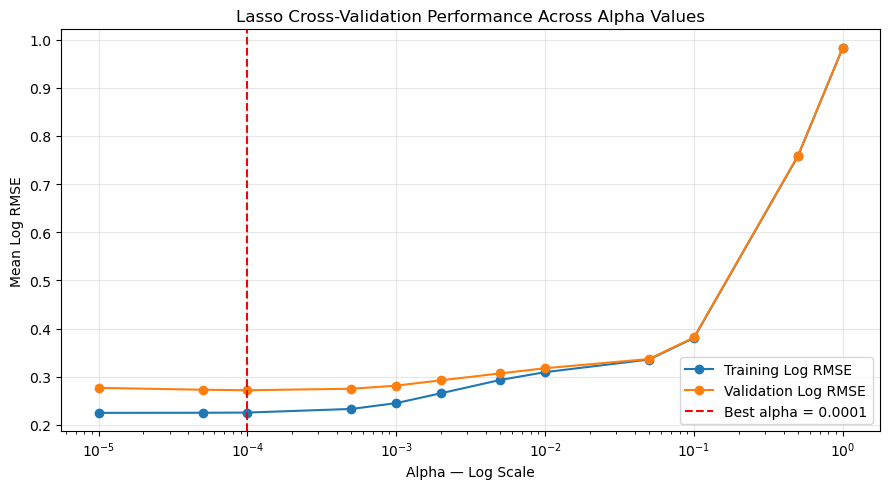

In [14]:
figure_directory = Path("../results/figures")
figure_directory.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 5))

plt.plot(
    lasso_cv_results["Alpha"],
    lasso_cv_results["Mean Train Log RMSE"],
    marker="o",
    label="Training Log RMSE"
)

plt.plot(
    lasso_cv_results["Alpha"],
    lasso_cv_results["Mean Validation Log RMSE"],
    marker="o",
    label="Validation Log RMSE"
)

plt.axvline(
    best_lasso_alpha,
    color="red",
    linestyle="--",
    label=f"Best alpha = {best_lasso_alpha}"
)

plt.xscale("log")
plt.xlabel("Alpha — Log Scale")
plt.ylabel("Mean Log RMSE")
plt.title("Lasso Cross-Validation Performance Across Alpha Values")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    figure_directory / "lasso_alpha_cv_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Alpha Performance Plot Observations

- The validation Log RMSE reaches its lowest point near `alpha=0.0001`.
- Very small alpha values retain a visible gap between training and validation error.
- Moderate and large alpha values increase both errors, showing progressively stronger underfitting.
- At high alpha values, the training and validation curves become close because Lasso removes most predictive information.
- The plot visually supports the cross-validation selection of `alpha=0.0001`.

## 9. Fit the Best Lasso Regression Model

The cross-validation-selected `alpha=0.0001` will now be used to build the best Lasso pipeline.

The complete pipeline will be fitted on all training observations using the log-transformed target. The test set remains unused during fitting and will only be used in the next step for final prediction and evaluation.

In [15]:
best_lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("lasso", Lasso(
        alpha=best_lasso_alpha,
        max_iter=50000
    ))
])

best_lasso_model.fit(X_train_fe, y_train_log)

print("Best Lasso model fitted successfully.")
print("Selected alpha:", best_lasso_alpha)

Best Lasso model fitted successfully.
Selected alpha: 0.0001


### 9.1 Generate Best Lasso Predictions

The fitted best Lasso model will generate predictions for the 412 test observations.

Predictions will first be produced on the log-transformed target scale and then converted back to the original Price scale using `expm1`. Negative predictions and initial predicted values will also be checked.

In [16]:
best_lasso_log_predictions = best_lasso_model.predict(
    X_test_fe
)

best_lasso_price_predictions = np.expm1(
    best_lasso_log_predictions
)

print("Predictions generated:", len(best_lasso_price_predictions))
print("Negative predictions:", (best_lasso_price_predictions < 0).sum())
print(
    "First five predicted prices:",
    best_lasso_price_predictions[:5].round(2)
)

Predictions generated: 412
Negative predictions: 0
First five predicted prices: [4335495.64  733974.08  574754.58 1159896.68  608794.83]


C:\Users\mamona\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### Best Lasso Prediction Observations

- Predictions were generated for all 412 test observations.
- The tuned Lasso model produced no negative Price predictions.
- Unlike the basic model, the predicted values vary across cars.
- This confirms that `alpha=0.0001` retains useful predictive information while applying L1 regularization.
- Final model quality must now be determined using MAE, RMSE, and R².

### 9.2 Evaluate the Best Lasso Model

The final tuned Lasso predictions will be evaluated on the untouched test set using original car prices.

MAE, RMSE, and R² will be calculated using the same definitions and test observations used for Linear and Ridge Regression. This ensures a direct and fair performance comparison.

In [17]:
best_lasso_mae = mean_absolute_error(
    y_test,
    best_lasso_price_predictions
)

best_lasso_rmse = np.sqrt(
    mean_squared_error(y_test, best_lasso_price_predictions)
)

best_lasso_r2 = r2_score(
    y_test,
    best_lasso_price_predictions
)

print("Best Lasso Regression Results")
print("Selected alpha:", best_lasso_alpha)
print("MAE:", round(best_lasso_mae, 2))
print("RMSE:", round(best_lasso_rmse, 2))
print("R²:", round(best_lasso_r2, 4))

Best Lasso Regression Results
Selected alpha: 0.0001
MAE: 298435.95
RMSE: 1003503.57
R²: 0.8559


### Best Lasso Evaluation Observations

- The tuned Lasso model achieved an MAE of approximately 298,436.
- Its RMSE is approximately 1,003,504.
- The R² value of 0.8559 indicates that the model explains about 85.6% of test-set Price variation.
- Cross-validation tuning produced a major improvement over the severely underfitted basic Lasso model.
- The larger RMSE relative to MAE suggests that a small number of expensive-car prediction errors still have a strong influence.
- The tuned model generated no negative Price predictions.

## 10. Compare Lasso with Linear and Ridge Regression

The saved Log-Target Linear and Ridge results will be loaded and combined with the Basic and Best Lasso results.

All models use the same train-test split, feature engineering, preprocessing approach, log-transformed target, and evaluation metrics. Therefore, differences in test performance can be compared fairly.

The comparison will consider predictive accuracy, negative predictions, regularization strength, and the effect of alpha tuning.

In [18]:
previous_model_results = pd.read_csv(
    "../results/ridge_model_comparison.csv"
)

lasso_result_rows = pd.DataFrame({
    "Model": [
        "Basic Lasso Regression",
        "Best Lasso Regression"
    ],
    "Alpha": [
        1.0,
        best_lasso_alpha
    ],
    "MAE": [
        basic_lasso_mae,
        best_lasso_mae
    ],
    "RMSE": [
        basic_lasso_rmse,
        best_lasso_rmse
    ],
    "R2": [
        basic_lasso_r2,
        best_lasso_r2
    ],
    "Negative Predictions": [
        (basic_lasso_price_predictions < 0).sum(),
        (best_lasso_price_predictions < 0).sum()
    ]
})

lasso_model_comparison = pd.concat(
    [previous_model_results, lasso_result_rows],
    ignore_index=True
)

lasso_model_comparison.round({
    "Alpha": 5,
    "MAE": 2,
    "RMSE": 2,
    "R2": 4
})

,Model,Alpha,MAE,RMSE,R2,Negative Predictions
0,Log-Target Linear Regression,NaN,302345.26,996774.47,0.8578,0
1,Basic Ridge Regression,1.0000,301740.34,990955.15,0.8594,0
2,Best Ridge Regression,0.5000,301182.74,999198.60,0.8571,0
3,Basic Lasso Regression,1.0000,1244715.96,2743961.98,-0.0777,0
4,Best Lasso Regression,0.0001,298435.95,1003503.57,0.8559,0


### Model Comparison Observations

- Best Lasso achieves the lowest MAE of approximately 298,436 among the compared models.
- Basic Ridge has the lowest test RMSE and highest test R², while the cross-validation-selected Best Ridge remains very close.
- Best Lasso has a slightly higher RMSE and slightly lower R² than Log-Target Linear and Ridge Regression.
- This indicates that Lasso improves the typical absolute prediction error but is slightly more affected by a small number of large errors.
- Basic Lasso at `alpha=1.0` performs poorly, confirming the importance of alpha tuning.
- All log-target models produce zero negative Price predictions.
- No model dominates every metric; Lasso must also be judged by the sparsity and feature-selection benefits of its coefficients.

## 11. Analyze Lasso Coefficients and Feature Selection

Lasso applies an L1 penalty that can shrink weak coefficients exactly to zero. Features with non-zero coefficients are retained by the fitted model, while zero-coefficient features are excluded from its linear prediction equation.

The analysis will:

- count total, selected, and zero coefficients,
- report the model intercept,
- rank retained features by absolute coefficient magnitude,
- inspect how much feature sparsity was created.

Coefficients are estimated for the log-transformed target and represent associations after controlling for the other encoded features. They should not be interpreted as causal effects.

In [19]:
lasso_feature_names = best_lasso_model[
    "preprocessor"
].get_feature_names_out()

lasso_feature_names = pd.Series(
    lasso_feature_names
).str.replace(
    "num__", "", regex=False
).str.replace(
    "cat__", "", regex=False
)

lasso_coefficients = best_lasso_model[
    "lasso"
].coef_

lasso_intercept = best_lasso_model[
    "lasso"
].intercept_

lasso_coefficient_table = pd.DataFrame({
    "Feature": lasso_feature_names,
    "Lasso Coefficient": lasso_coefficients
})

lasso_coefficient_table["Absolute Lasso Coefficient"] = (
    lasso_coefficient_table["Lasso Coefficient"].abs()
)

lasso_coefficient_table["Selected"] = (
    lasso_coefficient_table["Lasso Coefficient"] != 0
)

lasso_selected_coefficients = lasso_coefficient_table[
    lasso_coefficient_table["Selected"]
].sort_values(
    "Absolute Lasso Coefficient",
    ascending=False
).reset_index(drop=True)

total_lasso_coefficients = len(lasso_coefficient_table)
selected_lasso_coefficients = lasso_coefficient_table["Selected"].sum()
zero_lasso_coefficients = (
    total_lasso_coefficients - selected_lasso_coefficients
)

print("Total coefficients:", total_lasso_coefficients)
print("Selected non-zero coefficients:", selected_lasso_coefficients)
print("Exactly zero coefficients:", zero_lasso_coefficients)
print("Lasso intercept:", round(lasso_intercept, 4))

lasso_selected_coefficients.head(15).round(4)

Total coefficients: 160
Selected non-zero coefficients: 135
Exactly zero coefficients: 25
Lasso intercept: 14.3057


,Feature,Lasso Coefficient,Absolute Lasso Coefficient,Selected
0,Make_Datsun,-0.9109,0.9109,True
1,Make_Chevrolet,-0.7976,0.7976,True
2,Make_Tata,-0.7590,0.7590,True
3,Make_Renault,-0.7389,0.7389,True
4,Make_Nissan,-0.7338,0.7338,True
5,Make_MG,-0.6351,0.6351,True
6,Owner_infrequent_sklearn,-0.5928,0.5928,True
7,Make_Mahindra,-0.5823,0.5823,True
8,Make_Maruti Suzuki,-0.5729,0.5729,True
9,Make_Volkswagen,-0.5665,0.5665,True


### Lasso Coefficient Observations

- The fitted Lasso model contains 160 processed coefficients.
- It retains 135 non-zero coefficients and sets 25 coefficients exactly to zero.
- This produces a sparsity rate of approximately 15.63%.
- Lasso therefore reduces the active feature set while maintaining competitive predictive performance.
- The largest absolute coefficients are mostly associated with car-make categories.
- Categorical coefficients are interpreted relative to their dropped reference categories while holding other features constant.
- A negative make coefficient does not mean that every car from that make is inexpensive; it represents a lower expected log Price relative to the reference make after controlling for other features.
- The intercept of 14.3057 is on the log-Price scale and is not directly interpretable as the average car price.

### 11.1 Inspect Features Removed by Lasso

Features with coefficients exactly equal to zero will be listed.

These features do not contribute to predictions in the fitted best Lasso model. However, a zero coefficient does not prove that a feature is universally irrelevant. Lasso may remove one feature while retaining another correlated feature that contains similar information.

In [20]:
lasso_removed_features = lasso_coefficient_table[
    lasso_coefficient_table["Selected"] == False
][
    ["Feature", "Lasso Coefficient"]
].reset_index(drop=True)

print("Features removed by Lasso:", len(lasso_removed_features))

lasso_removed_features

Features removed by Lasso: 25


,Feature,Lasso Coefficient
0,missingindicator_Height,-0.0
1,missingindicator_Seating Capacity,-0.0
2,missingindicator_Fuel Tank Capacity,-0.0
3,missingindicator_Power_RPM,0.0
4,Make_Volvo,0.0
5,Model_Alto VXi,0.0
6,Model_Celerio VXi AMT,0.0
7,Model_City V,0.0
8,Model_Creta SX 1.6 AT Petrol,0.0
9,Model_GLA 200 d Sport,0.0


### Removed Feature Observations

- Lasso removed 25 processed features by setting their coefficients exactly to zero.
- The removed set includes four numerical missing-value indicators and several specific make, model, location, color, and seller-type categories.
- Most removed features are categorical levels rather than core continuous vehicle measurements.
- Values displayed as `-0.0` are numerically equal to zero.
- These features provided insufficient additional predictive contribution under the selected L1 penalty after accounting for the retained features.
- Their removal is specific to this training sample, preprocessing design, and selected alpha.

## 12. Compare Linear, Ridge, and Lasso Coefficients

The saved Linear-versus-Ridge coefficient comparison will be loaded and matched with the best Lasso coefficients.

This comparison will examine:

- how L1 and L2 regularization change coefficient magnitudes,
- which features Lasso removes completely,
- how the overall coefficient norms differ,
- how multicollinearity affects feature selection and interpretation.

All coefficients come from models trained on the same log-transformed target and comparable processed features.

In [21]:
linear_ridge_coefficients = pd.read_csv(
    "../results/linear_vs_ridge_coefficients.csv"
)

print("Shape:", linear_ridge_coefficients.shape)
print("Columns:", linear_ridge_coefficients.columns.tolist())

linear_ridge_coefficients.head()

Shape: (160, 6)
Columns: ['Feature', 'Linear Coefficient', 'Ridge Coefficient', 'Absolute Linear Coefficient', 'Absolute Ridge Coefficient', 'Magnitude Change']


,Feature,Linear Coefficient,Ridge Coefficient,Absolute Linear Coefficient,Absolute Ridge Coefficient,Magnitude Change
0,Make_Datsun,-0.994248,-0.825951,0.994248,0.825951,0.168298
1,Make_Chevrolet,-0.885514,-0.721959,0.885514,0.721959,0.163555
2,Make_Nissan,-0.808878,-0.677517,0.808878,0.677517,0.131361
3,Make_MG,-0.704949,-0.579533,0.704949,0.579533,0.125417
4,Make_Renault,-0.801005,-0.685134,0.801005,0.685134,0.115871


### Saved Coefficient Validation Observations

- The saved coefficient file contains 160 processed features and six comparison columns.
- Signed and absolute coefficients are available for both Linear and Ridge Regression.
- The feature names are already cleaned and suitable for matching with the Lasso coefficient table.
- The file can now be safely extended with Lasso coefficients.

### 12.1 Match and Combine the Coefficients

The cleaned Lasso coefficient table will be merged with the saved Linear-versus-Ridge comparison using the feature name.

An inner merge will retain only correctly matched features. The number of matched rows will then be validated against the expected 160 processed features before any coefficient comparison is performed.

In [22]:
lasso_coefficients_for_merge = lasso_coefficient_table[
    [
        "Feature",
        "Lasso Coefficient",
        "Absolute Lasso Coefficient",
        "Selected"
    ]
]

coefficient_comparison = linear_ridge_coefficients.merge(
    lasso_coefficients_for_merge,
    on="Feature",
    how="inner"
)

print("Linear and Ridge features:", len(linear_ridge_coefficients))
print("Lasso features:", len(lasso_coefficients_for_merge))
print("Matched features:", len(coefficient_comparison))

if len(coefficient_comparison) != 160:
    raise ValueError("All 160 features were not matched.")

coefficient_comparison.head().round(4)

Linear and Ridge features: 160
Lasso features: 160
Matched features: 160


,Feature,Linear Coefficient,Ridge Coefficient,Absolute Linear Coefficient,Absolute Ridge Coefficient,Magnitude Change,Lasso Coefficient,Absolute Lasso Coefficient,Selected
0,Make_Datsun,-0.9942,-0.8260,0.9942,0.8260,0.1683,-0.9109,0.9109,True
1,Make_Chevrolet,-0.8855,-0.7220,0.8855,0.7220,0.1636,-0.7976,0.7976,True
2,Make_Nissan,-0.8089,-0.6775,0.8089,0.6775,0.1314,-0.7338,0.7338,True
3,Make_MG,-0.7049,-0.5795,0.7049,0.5795,0.1254,-0.6351,0.6351,True
4,Make_Renault,-0.8010,-0.6851,0.8010,0.6851,0.1159,-0.7389,0.7389,True


### Coefficient Matching Observations

- All 160 Linear and Ridge features were successfully matched with the 160 Lasso features.
- No processed feature was lost during the merge.
- The coefficient values now represent the same encoded features across all three models.
- The combined table is valid for direct shrinkage and sparsity analysis.

### 12.2 Quantify Coefficient Shrinkage and Sparsity

The overall coefficient magnitudes will be compared using L1 and L2 norms.

The analysis will also count:

- how many Lasso coefficients moved closer to zero than Linear coefficients,
- how many Lasso coefficients are smaller than Ridge coefficients,
- how many coefficients were set exactly to zero.

Smaller coefficient norms indicate stronger overall shrinkage, but they do not automatically prove better predictive performance.

In [23]:
linear_l1_norm = coefficient_comparison[
    "Absolute Linear Coefficient"
].sum()

ridge_l1_norm = coefficient_comparison[
    "Absolute Ridge Coefficient"
].sum()

lasso_l1_norm = coefficient_comparison[
    "Absolute Lasso Coefficient"
].sum()

linear_l2_norm = np.linalg.norm(
    coefficient_comparison["Linear Coefficient"]
)

ridge_l2_norm = np.linalg.norm(
    coefficient_comparison["Ridge Coefficient"]
)

lasso_l2_norm = np.linalg.norm(
    coefficient_comparison["Lasso Coefficient"]
)

lasso_l2_reduction = (
    (linear_l2_norm - lasso_l2_norm) / linear_l2_norm
) * 100

lasso_closer_than_linear = (
    coefficient_comparison["Absolute Lasso Coefficient"]
    < coefficient_comparison["Absolute Linear Coefficient"]
).sum()

lasso_smaller_than_ridge = (
    coefficient_comparison["Absolute Lasso Coefficient"]
    < coefficient_comparison["Absolute Ridge Coefficient"]
).sum()

coefficient_comparison["Lasso Magnitude Change from Linear"] = (
    coefficient_comparison["Absolute Linear Coefficient"]
    - coefficient_comparison["Absolute Lasso Coefficient"]
)

top_lasso_shrinkage = coefficient_comparison.sort_values(
    "Lasso Magnitude Change from Linear",
    ascending=False
).reset_index(drop=True)

print("Linear coefficient L1 norm:", round(linear_l1_norm, 4))
print("Ridge coefficient L1 norm:", round(ridge_l1_norm, 4))
print("Lasso coefficient L1 norm:", round(lasso_l1_norm, 4))
print()
print("Linear coefficient L2 norm:", round(linear_l2_norm, 4))
print("Ridge coefficient L2 norm:", round(ridge_l2_norm, 4))
print("Lasso coefficient L2 norm:", round(lasso_l2_norm, 4))
print("Lasso L2 norm reduction from Linear:", round(lasso_l2_reduction, 2), "%")
print()
print("Lasso coefficients closer to zero than Linear:", lasso_closer_than_linear)
print("Lasso coefficients smaller than Ridge:", lasso_smaller_than_ridge)
print("Exactly zero Lasso coefficients:", zero_lasso_coefficients)

top_lasso_shrinkage[
    [
        "Feature",
        "Linear Coefficient",
        "Ridge Coefficient",
        "Lasso Coefficient",
        "Lasso Magnitude Change from Linear"
    ]
].head(15).round(4)

Linear coefficient L1 norm: 25.742
Ridge coefficient L1 norm: 21.1926
Lasso coefficient L1 norm: 20.0618

Linear coefficient L2 norm: 3.2472
Ridge coefficient L2 norm: 2.7547
Lasso coefficient L2 norm: 2.8838
Lasso L2 norm reduction from Linear: 11.19 %

Lasso coefficients closer to zero than Linear: 132
Lasso coefficients smaller than Ridge: 117
Exactly zero Lasso coefficients: 25


,Feature,Linear Coefficient,Ridge Coefficient,Lasso Coefficient,Lasso Magnitude Change from Linear
0,Color_infrequent_sklearn,0.2383,0.1328,0.0699,0.1683
1,Color_Orange,0.1866,0.0866,0.0338,0.1528
2,Color_Gold,0.1553,0.0679,0.0190,0.1363
3,Color_Brown,0.1401,0.0504,0.0053,0.1348
4,Color_Grey,0.1468,0.0579,0.0124,0.1344
5,Color_Red,0.1400,0.0533,0.0065,0.1335
6,Color_Black,0.1320,0.0449,0.0000,0.1320
7,Color_Green,0.1313,0.0560,0.0011,0.1302
8,Color_White,0.1402,0.0557,0.0104,0.1298
9,Color_Blue,0.1392,0.0597,0.0124,0.1268


### Coefficient Shrinkage Observations

- The coefficient L1 norm decreases from 25.7420 for Linear Regression to 21.1926 for Ridge and 20.0618 for Lasso.
- Lasso has the smallest L1 norm because its penalty directly controls the sum of absolute coefficient magnitudes.
- The L2 norm decreases from 3.2472 for Linear to 2.7547 for Ridge and 2.8838 for Lasso.
- Ridge has the smallest L2 norm because it directly penalizes squared coefficient magnitudes.
- Lasso reduces its L2 norm by 11.19% relative to Linear Regression.
- A total of 132 out of 160 Lasso coefficients move closer to zero than their Linear counterparts.
- Lasso coefficients are smaller than Ridge coefficients for 117 features and exactly zero for 25 features.
- The largest Lasso reductions are concentrated among color and location categories, suggesting that many of these encoded effects add limited unique information.
- Lasso may still produce larger coefficients than Ridge for some features because L1 and L2 penalties optimize different objectives.

### 12.3 Visualize Linear, Ridge, and Lasso Coefficient Shrinkage

The 15 features with the largest magnitude reductions from Linear to Lasso will be visualized.

Absolute coefficient magnitudes will be used so that the chart focuses on shrinkage strength rather than coefficient direction. Ridge and Lasso bars will show how L2 and L1 regularization affect the same features differently.

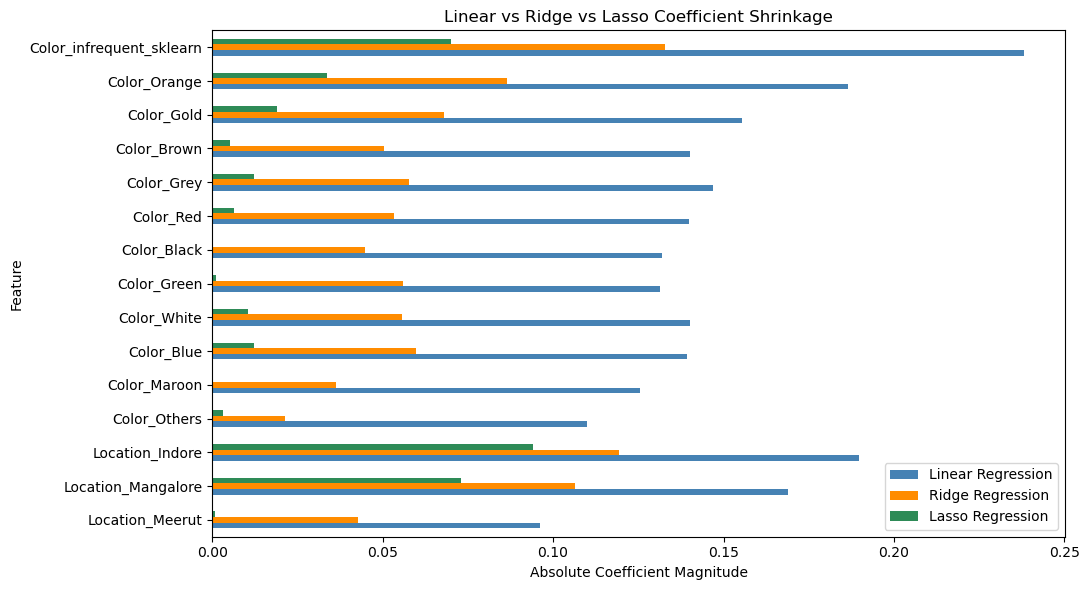

In [25]:
lasso_shrinkage_plot_data = top_lasso_shrinkage.head(
    15
).sort_values(
    "Lasso Magnitude Change from Linear"
).set_index(
    "Feature"
)[
    [
        "Absolute Linear Coefficient",
        "Absolute Ridge Coefficient",
        "Absolute Lasso Coefficient"
    ]
]

lasso_shrinkage_plot_data.columns = [
    "Linear Regression",
    "Ridge Regression",
    "Lasso Regression"
]

lasso_shrinkage_plot_data.plot(
    kind="barh",
    figsize=(11, 6),
    color=["steelblue", "darkorange", "seagreen"]
)

plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Feature")
plt.title("Linear vs Ridge vs Lasso Coefficient Shrinkage")
plt.legend()
plt.tight_layout()

plt.savefig(
    figure_directory / "lasso_coefficient_shrinkage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Coefficient Shrinkage Plot Observations

- Linear Regression has the largest coefficient magnitudes for all displayed features.
- Ridge provides moderate shrinkage, while Lasso applies the strongest shrinkage for these selected features.
- Lasso sets `Color_Black` and `Color_Maroon` exactly to zero and reduces several other color effects close to zero.
- The plot supports Lasso's ability to create a simpler and sparser linear model.
- The chart intentionally displays features with the largest Linear-to-Lasso reductions. It should not be generalized to claim that Lasso is more strongly shrunk than Ridge for every feature.

## 13. Analyze Feature Selection Across Alpha Values

The number of non-zero coefficients will be measured for every tested alpha value.

The fitted training preprocessor will first transform the full training set into the same 160-feature space. A separate Lasso model will then be fitted for each alpha to count its selected features.

This is a training-only sparsity diagnostic. It is not used for hyperparameter selection or test-set evaluation.

In [26]:
X_train_processed = best_lasso_model[
    "preprocessor"
].transform(X_train_fe)

selected_feature_counts = []
zero_feature_counts = []

for alpha in alpha_values:
    lasso_alpha_model = Lasso(
        alpha=alpha,
        max_iter=50000
    )

    lasso_alpha_model.fit(
        X_train_processed,
        y_train_log
    )

    selected_count = np.count_nonzero(
        lasso_alpha_model.coef_
    )

    selected_feature_counts.append(selected_count)
    zero_feature_counts.append(
        X_train_processed.shape[1] - selected_count
    )

lasso_alpha_sparsity = pd.DataFrame({
    "Alpha": alpha_values,
    "Selected Features": selected_feature_counts,
    "Zero Coefficients": zero_feature_counts
})

print("Processed training shape:", X_train_processed.shape)

lasso_alpha_sparsity.round({"Alpha": 5})

Processed training shape: (1647, 160)


,Alpha,Selected Features,Zero Coefficients
0,0.00001,158,2
1,0.00005,148,12
2,0.00010,135,25
3,0.00050,84,76
4,0.00100,65,95
5,0.00200,47,113
6,0.00500,28,132
7,0.01000,17,143
8,0.05000,9,151
9,0.10000,6,154


### Alpha Sparsity Observations

- The number of selected features decreases consistently as alpha increases.
- At `alpha=0.00001`, Lasso retains 158 of 160 processed features.
- The selected `alpha=0.0001` retains 135 features and removes 25.
- At `alpha=0.0005`, the active feature count drops sharply to 84, but validation performance is already weaker.
- At `alpha=1.0`, all 160 coefficients become zero.
- The all-zero coefficient vector explains why the basic Lasso model produced the same prediction for every test observation.
- The selected alpha provides moderate sparsity without the severe predictive information loss caused by larger alpha values.

### 13.1 Visualize the Alpha-Sparsity Relationship

The number of selected features will be plotted against alpha on a logarithmic x-axis.

The graph will illustrate how stronger L1 regularization progressively removes features and will mark the cross-validation-selected alpha.

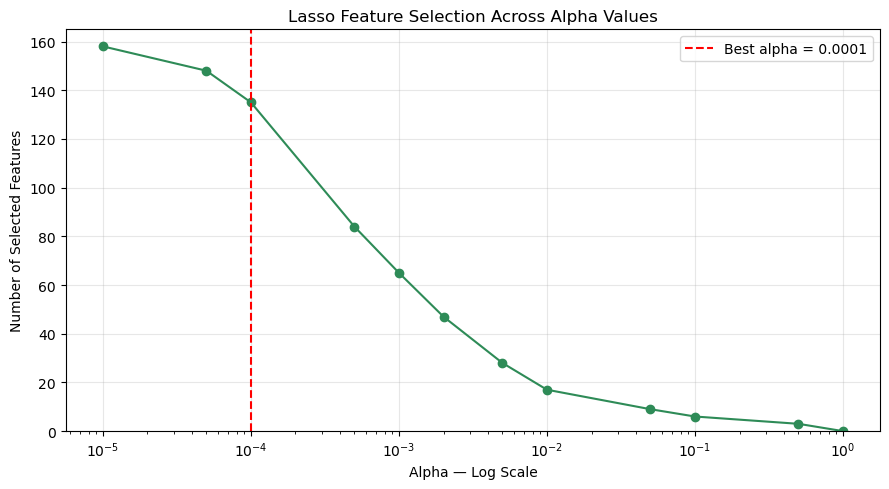

In [27]:
plt.figure(figsize=(9, 5))

plt.plot(
    lasso_alpha_sparsity["Alpha"],
    lasso_alpha_sparsity["Selected Features"],
    marker="o",
    color="seagreen"
)

plt.axvline(
    best_lasso_alpha,
    color="red",
    linestyle="--",
    label=f"Best alpha = {best_lasso_alpha}"
)

plt.xscale("log")
plt.xlabel("Alpha — Log Scale")
plt.ylabel("Number of Selected Features")
plt.title("Lasso Feature Selection Across Alpha Values")
plt.ylim(0, 165)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    figure_directory / "lasso_alpha_sparsity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Alpha-Sparsity Plot Observations

- Feature selection becomes more aggressive as alpha increases.
- The selected `alpha=0.0001` retains 135 features and lies just before a steep reduction in active features.
- Increasing alpha from 0.0001 to 0.0005 reduces the selected feature count from 135 to 84.
- This sharp decline shows that Lasso feature selection is sensitive to alpha.
- At `alpha=1.0`, no processed feature remains active.
- The sparsity curve must be interpreted together with the validation-error curve because fewer features do not automatically produce better predictions.

## 14. Evaluate Coefficient and Feature-Selection Stability

Strongly correlated predictors can make Lasso feature selection unstable. Across different training samples, Lasso may retain one correlated feature and remove another.

A five-fold post-selection diagnostic will fit Linear, best Ridge, and best Lasso models on the same fixed 160-feature training space. Coefficient variability and Lasso selection frequency will then be compared across folds.

The fixed processed matrix is used only to keep feature positions comparable for this diagnostic. These results are not used for hyperparameter selection or test performance estimation.

In [29]:
best_ridge_alpha = previous_model_results.loc[
    previous_model_results["Model"] == "Best Ridge Regression",
    "Alpha"
].iloc[0]

linear_stability_results = cross_validate(
    LinearRegression(),
    X_train_processed,
    y_train_log,
    cv=cv_strategy,
    return_estimator=True,
    n_jobs=-1
)

ridge_stability_results = cross_validate(
    Ridge(alpha=best_ridge_alpha),
    X_train_processed,
    y_train_log,
    cv=cv_strategy,
    return_estimator=True,
    n_jobs=-1
)

lasso_stability_results = cross_validate(
    Lasso(
        alpha=best_lasso_alpha,
        max_iter=50000
    ),
    X_train_processed,
    y_train_log,
    cv=cv_strategy,
    return_estimator=True,
    n_jobs=-1
)

linear_coefficient_matrix = np.vstack([
    model.coef_
    for model in linear_stability_results["estimator"]
])

ridge_coefficient_matrix = np.vstack([
    model.coef_
    for model in ridge_stability_results["estimator"]
])

lasso_coefficient_matrix = np.vstack([
    model.coef_
    for model in lasso_stability_results["estimator"]
])

print("Processed training shape:", X_train_processed.shape)
print("Linear coefficient matrix:", linear_coefficient_matrix.shape)
print("Ridge coefficient matrix:", ridge_coefficient_matrix.shape)
print("Lasso coefficient matrix:", lasso_coefficient_matrix.shape)

Processed training shape: (1647, 160)
Linear coefficient matrix: (5, 160)
Ridge coefficient matrix: (5, 160)
Lasso coefficient matrix: (5, 160)


### Stability Diagnostic Setup Observations

- The fixed processed training matrix contains 1,647 observations and 160 features.
- Each model produced five coefficient vectors, one from every cross-validation fold.
- All three coefficient matrices have the expected shape of `(5, 160)`.
- Feature positions remain aligned across models and folds, so coefficient variability can be compared safely.

### 14.1 Quantify Coefficient and Selection Stability

Coefficient stability will be measured using the standard deviation of each feature's coefficient across the five folds. A lower standard deviation indicates a more stable coefficient estimate.

For Lasso, selection frequency will also be calculated as the percentage of folds in which each coefficient is non-zero. Features selected in every fold are more stable than features selected only occasionally.

In [30]:
lasso_selection_counts = (
    lasso_coefficient_matrix != 0
).sum(axis=0)

lasso_stability_table = pd.DataFrame({
    "Feature": lasso_feature_names,
    "Linear Coefficient SD": linear_coefficient_matrix.std(
        axis=0,
        ddof=1
    ),
    "Ridge Coefficient SD": ridge_coefficient_matrix.std(
        axis=0,
        ddof=1
    ),
    "Lasso Coefficient SD": lasso_coefficient_matrix.std(
        axis=0,
        ddof=1
    ),
    "Lasso Folds Selected": lasso_selection_counts
})

lasso_stability_table["Lasso Selection Frequency (%)"] = (
    lasso_stability_table["Lasso Folds Selected"] / 5
) * 100

lasso_more_stable_than_linear = (
    lasso_stability_table["Lasso Coefficient SD"]
    < lasso_stability_table["Linear Coefficient SD"]
).sum()

lasso_more_stable_than_ridge = (
    lasso_stability_table["Lasso Coefficient SD"]
    < lasso_stability_table["Ridge Coefficient SD"]
).sum()

selected_all_folds = (
    lasso_stability_table["Lasso Folds Selected"] == 5
).sum()

selected_some_folds = (
    (lasso_stability_table["Lasso Folds Selected"] > 0)
    & (lasso_stability_table["Lasso Folds Selected"] < 5)
).sum()

selected_no_folds = (
    lasso_stability_table["Lasso Folds Selected"] == 0
).sum()

variable_lasso_selection = lasso_stability_table[
    (lasso_stability_table["Lasso Folds Selected"] > 0)
    & (lasso_stability_table["Lasso Folds Selected"] < 5)
].sort_values(
    ["Lasso Folds Selected", "Lasso Coefficient SD"],
    ascending=[True, False]
).reset_index(drop=True)

print(
    "Mean coefficient SD — Linear:",
    round(lasso_stability_table["Linear Coefficient SD"].mean(), 4)
)
print(
    "Mean coefficient SD — Ridge:",
    round(lasso_stability_table["Ridge Coefficient SD"].mean(), 4)
)
print(
    "Mean coefficient SD — Lasso:",
    round(lasso_stability_table["Lasso Coefficient SD"].mean(), 4)
)
print()
print(
    "Median coefficient SD — Linear:",
    round(lasso_stability_table["Linear Coefficient SD"].median(), 4)
)
print(
    "Median coefficient SD — Ridge:",
    round(lasso_stability_table["Ridge Coefficient SD"].median(), 4)
)
print(
    "Median coefficient SD — Lasso:",
    round(lasso_stability_table["Lasso Coefficient SD"].median(), 4)
)
print()
print("Lasso more stable than Linear:", lasso_more_stable_than_linear)
print("Lasso more stable than Ridge:", lasso_more_stable_than_ridge)
print("Selected in all 5 folds:", selected_all_folds)
print("Selected in some folds:", selected_some_folds)
print("Selected in no folds:", selected_no_folds)

variable_lasso_selection.head(15).round(4)

Mean coefficient SD — Linear: 0.0518
Mean coefficient SD — Ridge: 0.0323
Mean coefficient SD — Lasso: 0.0299

Median coefficient SD — Linear: 0.0464
Median coefficient SD — Ridge: 0.0253
Median coefficient SD — Lasso: 0.0238

Lasso more stable than Linear: 130
Lasso more stable than Ridge: 88
Selected in all 5 folds: 95
Selected in some folds: 63
Selected in no folds: 2


,Feature,Linear Coefficient SD,Ridge Coefficient SD,Lasso Coefficient SD,Lasso Folds Selected,Lasso Selection Frequency (%)
0,Model_Swift VXi [2014-2017],0.0822,0.0232,0.0164,1,20.0
1,Model_GLE 250 d,0.0464,0.0263,0.0141,1,20.0
2,Model_Vitara Brezza VDi (O) [2016-2018],0.1019,0.0329,0.0069,1,20.0
3,Model_GLE 300d 4MATIC LWB,0.0945,0.0335,0.0062,1,20.0
4,Model_City V,0.0830,0.0200,0.0061,1,20.0
5,Model_Alto VXi,0.0722,0.0103,0.0039,1,20.0
6,Model_Creta SX 1.6 AT Petrol,0.0799,0.0245,0.0036,1,20.0
7,Model_Wagon R VXI,0.0857,0.0225,0.0011,1,20.0
8,Model_V40 D3 R-Design,0.1381,0.0608,0.0417,2,40.0
9,Color_Maroon,0.0781,0.0500,0.0414,2,40.0


### Coefficient and Selection Stability Observations

- Mean coefficient SD decreases from 0.0518 for Linear to 0.0323 for Ridge and 0.0299 for Lasso.
- Median coefficient SD decreases from 0.0464 for Linear to 0.0253 for Ridge and 0.0238 for Lasso.
- Lasso produces more stable coefficient magnitudes than Linear for 130 of 160 features and than Ridge for 88 features.
- The lower Lasso SD partly reflects shrinkage and repeated movement of weak coefficients toward zero.
- Only 95 features are selected in all five folds.
- A total of 63 features are selected in some folds but excluded in others, while two features are never selected.
- Several low-frequency model categories are retained in only one or two folds.
- Therefore, Lasso improves overall coefficient-size stability but its exact feature-selection set remains sample-sensitive.
- This distinction is important under multicollinearity because correlated predictors can replace one another across folds.

### 14.2 Examine Lasso Coefficients for High-VIF Features

The saved numerical VIF comparison will be extended with Lasso coefficients.

This analysis will determine whether high-VIF numerical features remain active after L1 regularization and how their coefficient magnitudes differ across Linear, Ridge, and Lasso Regression.

VIF describes correlation among predictors and is not changed by fitting a regularized model. Regularization controls the model's response to multicollinearity rather than removing the underlying correlations.

In [32]:
ridge_vif_comparison = pd.read_csv(
    "../results/ridge_vif_coefficient_comparison.csv"
)

lasso_vif_comparison = ridge_vif_comparison.merge(
    lasso_coefficients_for_merge,
    on="Feature",
    how="inner"
).sort_values(
    "VIF",
    ascending=False
).reset_index(drop=True)

print("VIF features:", len(ridge_vif_comparison))
print("Matched numerical features:", len(lasso_vif_comparison))

if len(lasso_vif_comparison) != len(ridge_vif_comparison):
    raise ValueError("All VIF features were not matched.")

lasso_vif_comparison[
    [
        "Feature",
        "VIF",
        "Linear Coefficient",
        "Ridge Coefficient",
        "Lasso Coefficient",
        "Selected"
    ]
].round(4)

VIF features: 12
Matched numerical features: 12


,Feature,VIF,Linear Coefficient,Ridge Coefficient,Lasso Coefficient,Selected
0,Power_BHP,18.5668,0.3299,0.3277,0.3274,True
1,Torque_NM,17.8130,-0.1413,-0.1285,-0.1270,True
2,Engine_CC,8.7009,0.0248,0.0207,0.0184,True
3,Power_RPM,7.8623,0.0018,0.0050,0.0006,True
4,Length,5.8289,0.2246,0.2205,0.2218,True
5,Torque_RPM_Clean,4.5594,-0.0489,-0.0539,-0.0490,True
6,Fuel Tank Capacity,4.5303,0.0109,0.0198,0.0172,True
7,Width,4.2695,0.0202,0.0226,0.0212,True
8,Height,2.9507,0.0975,0.0825,0.0898,True
9,Seating Capacity,2.7245,-0.0456,-0.0425,-0.0438,True


### High-VIF Feature Observations

- All 12 numerical VIF features remain active in the best Lasso model.
- `Power_BHP` and `Torque_NM`, with VIF values above 17, retain substantial coefficients across Linear, Ridge, and Lasso Regression.
- Lasso modestly shrinks several correlated technical features but does not eliminate them at the selected weak penalty.
- `Power_RPM` has a very small Lasso coefficient of 0.0006 but is not exactly zero.
- High VIF does not automatically make a predictor useless or guarantee its removal by Lasso.
- The original predictor correlations and VIF values remain unchanged after regularization.
- Coefficients of strongly correlated features should still be interpreted cautiously because their individual contributions are difficult to separate.

## 15. Visualize Actual vs Predicted Prices

Actual test prices will be plotted against the best Lasso predictions.

A dashed diagonal line will represent perfect predictions. Points close to this line indicate accurate predictions, while larger distances indicate greater errors.

Both axes will use logarithmic scaling so that low-, medium-, and high-price cars can be examined within the same figure.

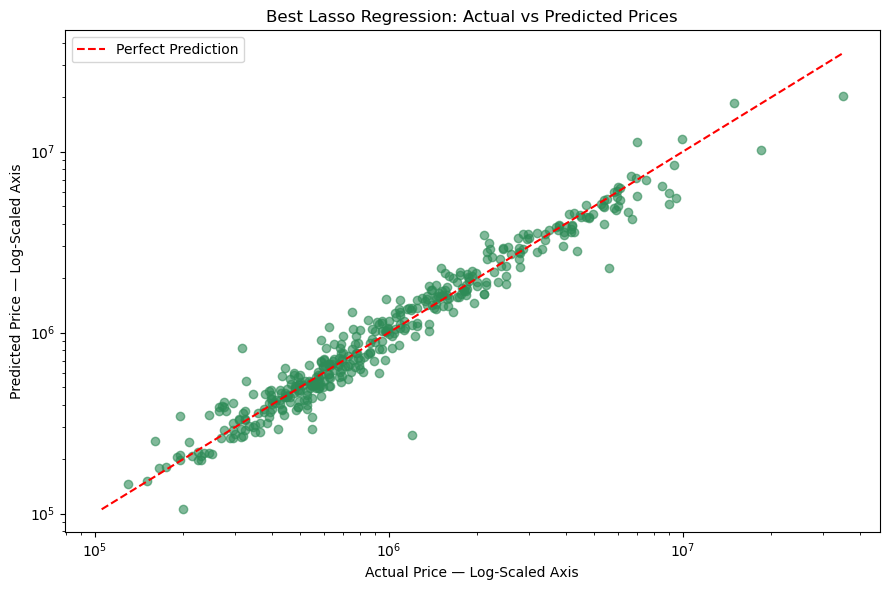

In [33]:
plot_minimum = min(
    y_test.min(),
    best_lasso_price_predictions.min()
)

plot_maximum = max(
    y_test.max(),
    best_lasso_price_predictions.max()
)

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    best_lasso_price_predictions,
    alpha=0.6,
    color="seagreen"
)

plt.plot(
    [plot_minimum, plot_maximum],
    [plot_minimum, plot_maximum],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual Price — Log-Scaled Axis")
plt.ylabel("Predicted Price — Log-Scaled Axis")
plt.title("Best Lasso Regression: Actual vs Predicted Prices")
plt.legend()
plt.tight_layout()

plt.savefig(
    figure_directory / "lasso_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Actual vs Predicted Plot Observations

- Most observations cluster close to the perfect-prediction line across low- and medium-price ranges.
- The model captures the overall Price pattern well on the logarithmic scale.
- Prediction dispersion becomes more visible among high-price vehicles.
- Several expensive cars are underpredicted, while a smaller number are overpredicted.
- A few isolated large errors remain outside the main point cluster.
- These deviations are consistent with the model's strong MAE but slightly weaker RMSE.

## 16. Analyze Lasso Residuals

Residuals will be calculated as:

`Residual = Actual Price - Predicted Price`

A positive residual indicates underprediction, while a negative residual indicates overprediction.

Residuals will be examined on both the original Price scale and the log-transformed scale. The original scale reflects errors in currency units, while the log scale is more suitable for assessing the model trained on `log1p(Price)`.

In [34]:
lasso_original_residuals = pd.Series(
    y_test.to_numpy() - best_lasso_price_predictions
)

lasso_log_residuals = pd.Series(
    y_test_log.to_numpy() - best_lasso_log_predictions
)

print("Original Price Residuals")
print("Mean:", round(lasso_original_residuals.mean(), 2))
print("Median:", round(lasso_original_residuals.median(), 2))
print("Standard deviation:", round(lasso_original_residuals.std(), 2))
print("Positive residuals:", (lasso_original_residuals > 0).sum())
print("Negative residuals:", (lasso_original_residuals < 0).sum())

print()
print("Log-Scale Residuals")
print("Mean:", round(lasso_log_residuals.mean(), 4))
print("Median:", round(lasso_log_residuals.median(), 4))
print("Standard deviation:", round(lasso_log_residuals.std(), 4))

Original Price Residuals
Mean: 85940.01
Median: 1421.34
Standard deviation: 1001032.43
Positive residuals: 209
Negative residuals: 203

Log-Scale Residuals
Mean: 0.0034
Median: 0.0021
Standard deviation: 0.2108


### Residual Summary Observations

- The original-scale residual mean is approximately 85,940, indicating average underprediction in currency units.
- The median residual is only about 1,421, which is close to zero relative to the Price range.
- Positive and negative residual counts are balanced at 209 and 203.
- The positive mean is mainly influenced by a small number of large underpredictions for expensive cars.
- Log-scale residual mean and median are close to zero at 0.0034 and 0.0021.
- Log-scale residual standard deviation is 0.2108, indicating a relatively compact error distribution on the modeled scale.
- The difference between the original-scale mean and median confirms that extreme Price errors strongly affect average currency-scale residuals.

### 16.1 Visualize Residuals Against Predictions

Two residual plots will be created:

- original Price residuals against original-scale predictions,
- log-scale residuals against predicted log Price.

A horizontal zero line will represent perfect residual balance. Random scatter around zero is desirable, while visible patterns, changing spread, or isolated points may indicate remaining model limitations.

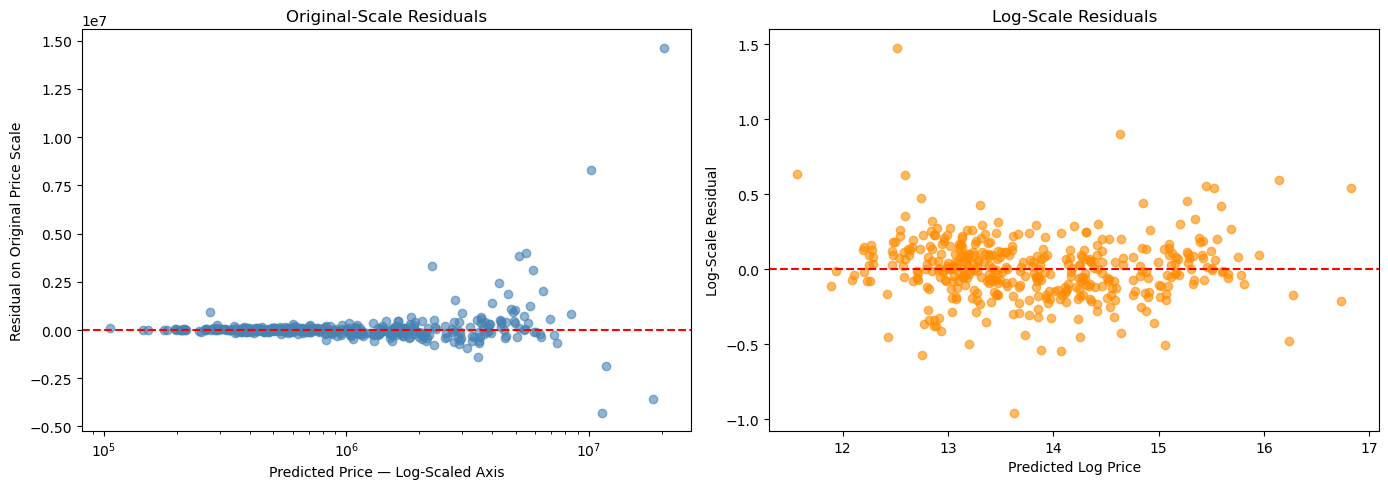

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    best_lasso_price_predictions,
    lasso_original_residuals,
    alpha=0.6,
    color="steelblue"
)

axes[0].axhline(
    0,
    color="red",
    linestyle="--"
)

axes[0].set_xscale("log")
axes[0].set_xlabel("Predicted Price — Log-Scaled Axis")
axes[0].set_ylabel("Residual on Original Price Scale")
axes[0].set_title("Original-Scale Residuals")

axes[1].scatter(
    best_lasso_log_predictions,
    lasso_log_residuals,
    alpha=0.6,
    color="darkorange"
)

axes[1].axhline(
    0,
    color="red",
    linestyle="--"
)

axes[1].set_xlabel("Predicted Log Price")
axes[1].set_ylabel("Log-Scale Residual")
axes[1].set_title("Log-Scale Residuals")

plt.tight_layout()

plt.savefig(
    figure_directory / "lasso_residuals_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Residual Plot Observations

- Original-scale residual spread increases as predicted Price increases.
- Several high-price vehicles have very large positive or negative residuals.
- This funnel-like pattern indicates heteroscedasticity on the original Price scale.
- Log-scale residuals are more evenly distributed around zero across most fitted values.
- The log transformation substantially improves variance stability but does not remove all structure or outliers.
- A few extreme log residuals remain, indicating unusually difficult observations.

### 16.2 Examine the Log-Residual Distribution

A histogram with a density curve will show the center, spread, and symmetry of the log-scale residuals.

A Q-Q plot will compare the ordered residuals with theoretical normal quantiles. Points close to the reference line support approximate normality, while tail deviations indicate outliers or heavy-tailed errors.

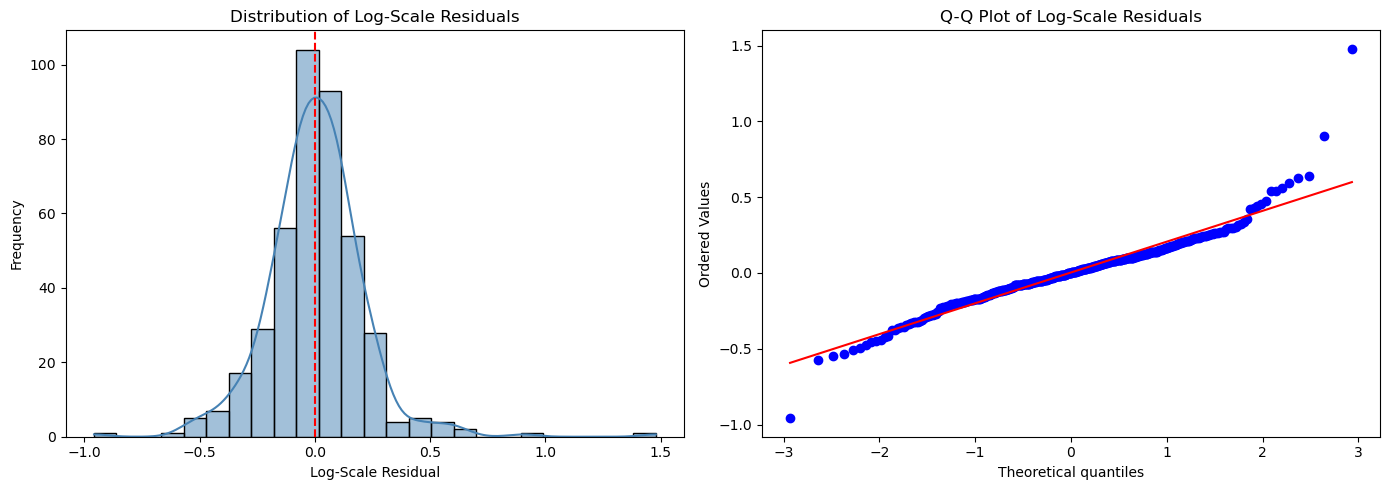

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    lasso_log_residuals,
    bins=25,
    kde=True,
    color="steelblue",
    ax=axes[0]
)

axes[0].axvline(
    0,
    color="red",
    linestyle="--"
)

axes[0].set_xlabel("Log-Scale Residual")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Log-Scale Residuals")

stats.probplot(
    lasso_log_residuals,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title("Q-Q Plot of Log-Scale Residuals")

plt.tight_layout()

plt.savefig(
    figure_directory / "lasso_log_residual_diagnostics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Log-Residual Distribution Observations

- The log-residual histogram is concentrated near zero and has an approximately bell-shaped central region.
- The distribution shows heavier tails than a perfect normal distribution.
- Most Q-Q points follow the reference line through the middle quantiles.
- Clear deviations occur in both tails, with stronger deviation in the upper tail.
- A small number of extreme positive and negative residuals remain.
- Therefore, log transformation improves residual behavior, but the normality assumption is only approximate rather than exact.

### 16.3 Inspect the Largest Prediction Errors

The test observations with the largest absolute Price errors will be identified.

Make, model, year, actual Price, predicted Price, residual direction, absolute error, and percentage error will be reviewed. This helps determine which vehicle segments are most difficult for the model and why RMSE remains sensitive to a few observations.

In [37]:
lasso_error_analysis = X_test[
    ["Make", "Model", "Year", "Kilometer", "Location"]
].reset_index(drop=True).copy()

lasso_error_analysis["Actual Price"] = y_test.to_numpy()
lasso_error_analysis["Predicted Price"] = best_lasso_price_predictions
lasso_error_analysis["Residual"] = lasso_original_residuals
lasso_error_analysis["Absolute Error"] = (
    lasso_error_analysis["Residual"].abs()
)

lasso_error_analysis["Percentage Error"] = (
    lasso_error_analysis["Absolute Error"]
    / lasso_error_analysis["Actual Price"]
) * 100

lasso_error_analysis["Error Direction"] = np.where(
    lasso_error_analysis["Residual"] > 0,
    "Underprediction",
    "Overprediction"
)

largest_lasso_errors = lasso_error_analysis.sort_values(
    "Absolute Error",
    ascending=False
).reset_index(drop=True)

largest_lasso_errors.head(10).round({
    "Predicted Price": 2,
    "Residual": 2,
    "Absolute Error": 2,
    "Percentage Error": 2
})

,Make,Model,Year,Kilometer,Location,Actual Price,Predicted Price,Residual,Absolute Error,Percentage Error,Error Direction
0,Ferrari,488 GTB,2018,9500,Delhi,35000000,20360771.41,14639228.59,14639228.59,41.83,Underprediction
1,Mercedes-Benz,S-Class S 350D [2018-2020],2021,5000,Pune,18500000,10206652.83,8293347.17,8293347.17,44.83,Underprediction
2,Mercedes-Benz,C-Coupe 43 AMG 4MATIC,2020,19000,Chennai,7000000,11293372.26,-4293372.26,4293372.26,61.33,Overprediction
3,Porsche,718 Boxster,2018,20000,Delhi,9500000,5516553.89,3983446.11,3983446.11,41.93,Underprediction
4,Porsche,718 Cayman [2017-2020],2017,7000,Faridabad,9000000,5147931.88,3852068.12,3852068.12,42.80,Underprediction
5,Porsche,Cayenne Base,2021,7534,Mumbai,14900000,18466365.68,-3566365.68,3566365.68,23.94,Overprediction
6,Porsche,Panamera 3.0 Diesel,2015,33000,Delhi,5590000,2264485.34,3325514.66,3325514.66,59.49,Underprediction
7,Maserati,Levante Diesel,2017,40000,Chennai,9000000,5910200.88,3089799.12,3089799.12,34.33,Underprediction
8,Audi,Q7 45 TDI Technology Pack,2018,39850,Surat,6700000,4261900.68,2438099.32,2438099.32,36.39,Underprediction
9,Volvo,XC90 D5 Inscription,2021,32500,Ahmedabad,8500000,6478263.14,2021736.86,2021736.86,23.79,Underprediction


### Largest Error Observations

- All ten largest absolute errors involve luxury or premium vehicles.
- Eight of the ten observations are underpredictions.
- The Ferrari 488 GTB has the largest absolute error at approximately 14.64 million, with a 41.83% error.
- The Mercedes-Benz S-Class has the second-largest error at approximately 8.29 million.
- Percentage errors among these observations range from about 23.79% to 61.33%.
- Rare luxury models have limited comparable training observations, making their prices difficult for a linear additive model to estimate.
- These errors explain the positive original-scale residual mean and the gap between MAE and RMSE.
- The observations should not be removed only because they are difficult; they represent a genuine high-value market segment requiring more data or more flexible models.

## 17. Research Interpretation

Five-fold training-only cross-validation selected a weak L1 penalty of `alpha=0.0001`, with a mean validation Log RMSE of 0.2718.

On the untouched test set, the tuned Lasso model achieved:

- MAE: 298,435.95
- RMSE: 1,003,503.57
- R²: 0.8559
- Negative predictions: 0

Lasso achieved the lowest MAE among the compared Linear and Ridge models, but its RMSE and R² were slightly weaker. This suggests improved typical absolute error but greater sensitivity to a few large luxury-vehicle errors.

The model set 25 of 160 coefficients exactly to zero, producing 15.63% sparsity. Its coefficient magnitudes were more stable than Linear Regression overall, but 63 features had inconsistent selection across folds. Therefore, Lasso provides useful feature reduction, although the exact selected set should not be treated as definitive under multicollinearity.

All high-VIF numerical features remained active. Lasso managed coefficient magnitude and sparsity but did not remove the underlying predictor correlations. These findings motivate Elastic Net as the next model because it can combine Ridge-style stability with Lasso-style feature selection.

## 18. Industry Interpretation

The tuned Lasso model is suitable as an interpretable baseline for general used-car price estimation.

Its practical strengths include:

- competitive average absolute error,
- no negative Price predictions,
- automatic removal of 25 weak processed features,
- preprocessing and prediction within one leakage-safe pipeline,
- safe handling of missing and unseen categories.

The model should not be used as the only pricing authority for rare luxury vehicles because the largest errors are concentrated in that segment. High-value predictions should include human review, wider uncertainty ranges, or a specialized luxury-car model.

Model choice should follow business cost. Lasso is attractive when typical absolute error and feature reduction are important. Ridge may be preferred when large errors and coefficient stability are given greater priority.

In deployment, category drift, luxury-segment errors, missing-data patterns, and prediction residuals should be monitored. The complete fitted pipeline—not only the Lasso estimator—would need to be saved and deployed.

## 19. Limitations

- The dataset contains only 2,059 observations, with limited examples for many premium and luxury models.
- High-cardinality categorical features create many sparse one-hot encoded columns.
- Some categories in the test set were unseen during training and were encoded as all zeros.
- `Vehicle_Age` is based on the fixed reference year 2022 and would require updating for future data.
- Lasso remains a linear additive model and cannot automatically capture complex non-linear relationships or feature interactions.
- Strong multicollinearity remains among technical vehicle features even after regularization.
- The exact Lasso-selected feature set changes across folds for 63 features.
- Direct `expm1` conversion of log predictions may introduce retransformation bias on the original Price scale.
- Residuals contain heavy tails and large luxury-segment errors.
- Alpha was selected using Log RMSE, while final business metrics were calculated on the original Price scale.
- Results are based on one fixed train-test split and should be validated on new external data.
- Coefficients represent conditional associations and should not be interpreted as causal effects.

## 20. Final Conclusion

The default Lasso model with `alpha=1.0` removed all coefficients and severely underfit the data. Training-only five-fold cross-validation selected `alpha=0.0001`, demonstrating that alpha tuning is essential.

The tuned Lasso model achieved:

- MAE: 298,435.95
- RMSE: 1,003,503.57
- R²: 0.8559
- Zero coefficients: 25 of 160
- Selected features: 135 of 160
- Negative predictions: 0

Lasso produced the lowest MAE among the compared models and created a moderately sparse solution. However, Ridge and Log-Target Linear Regression remained slightly stronger on RMSE and R².

The model improved overall coefficient stability, but exact feature selection remained sensitive across folds under multicollinearity. Lasso is therefore valuable when feature reduction and typical absolute error are important, while its selected features require cautious interpretation.

The next stage is Elastic Net Regression, which will combine L1 and L2 penalties to seek a better balance between sparsity and correlated-feature stability.

## 21. Save Lasso Results

Important Lasso tables will be saved in the `results/` directory for reproducibility, GitHub review, and later final-model comparison.

The saved outputs will include cross-validation results, model metrics, coefficients, sparsity, stability, VIF comparison, and largest prediction errors. Existing Linear and Ridge result files will not be overwritten.

In [38]:
results_directory = Path("../results")
results_directory.mkdir(parents=True, exist_ok=True)

lasso_cv_results.to_csv(
    results_directory / "lasso_alpha_cv_results.csv",
    index=False
)

lasso_model_comparison.to_csv(
    results_directory / "lasso_model_comparison.csv",
    index=False
)

lasso_coefficient_table.to_csv(
    results_directory / "lasso_regression_coefficients.csv",
    index=False
)

coefficient_comparison.to_csv(
    results_directory / "linear_ridge_lasso_coefficients.csv",
    index=False
)

lasso_alpha_sparsity.to_csv(
    results_directory / "lasso_alpha_sparsity.csv",
    index=False
)

lasso_stability_table.to_csv(
    results_directory / "lasso_coefficient_stability.csv",
    index=False
)

lasso_vif_comparison.to_csv(
    results_directory / "lasso_vif_coefficient_comparison.csv",
    index=False
)

largest_lasso_errors.to_csv(
    results_directory / "lasso_largest_prediction_errors.csv",
    index=False
)

print("Lasso result files saved successfully.")
print()
print("1. lasso_alpha_cv_results.csv")
print("2. lasso_model_comparison.csv")
print("3. lasso_regression_coefficients.csv")
print("4. linear_ridge_lasso_coefficients.csv")
print("5. lasso_alpha_sparsity.csv")
print("6. lasso_coefficient_stability.csv")
print("7. lasso_vif_coefficient_comparison.csv")
print("8. lasso_largest_prediction_errors.csv")

Lasso result files saved successfully.

1. lasso_alpha_cv_results.csv
2. lasso_model_comparison.csv
3. lasso_regression_coefficients.csv
4. linear_ridge_lasso_coefficients.csv
5. lasso_alpha_sparsity.csv
6. lasso_coefficient_stability.csv
7. lasso_vif_coefficient_comparison.csv
8. lasso_largest_prediction_errors.csv


### Saved Result Observations

The following Lasso result files were saved successfully:

1. `lasso_alpha_cv_results.csv`
2. `lasso_model_comparison.csv`
3. `lasso_regression_coefficients.csv`
4. `linear_ridge_lasso_coefficients.csv`
5. `lasso_alpha_sparsity.csv`
6. `lasso_coefficient_stability.csv`
7. `lasso_vif_coefficient_comparison.csv`
8. `lasso_largest_prediction_errors.csv`

Six Lasso figures were also saved in `results/figures/`. These outputs preserve the main performance, sparsity, stability, coefficient, and diagnostic evidence from the notebook.